# ASSIGNMENT 13 - XGBM & LGBM

In [50]:

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings("ignore")


In [51]:
# Load the dataset
df = pd.read_csv("diabetes.csv")

# Display first 5 rows
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [52]:
# Dataset structure and data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [53]:
# Check missing values
df.isnull().sum()


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

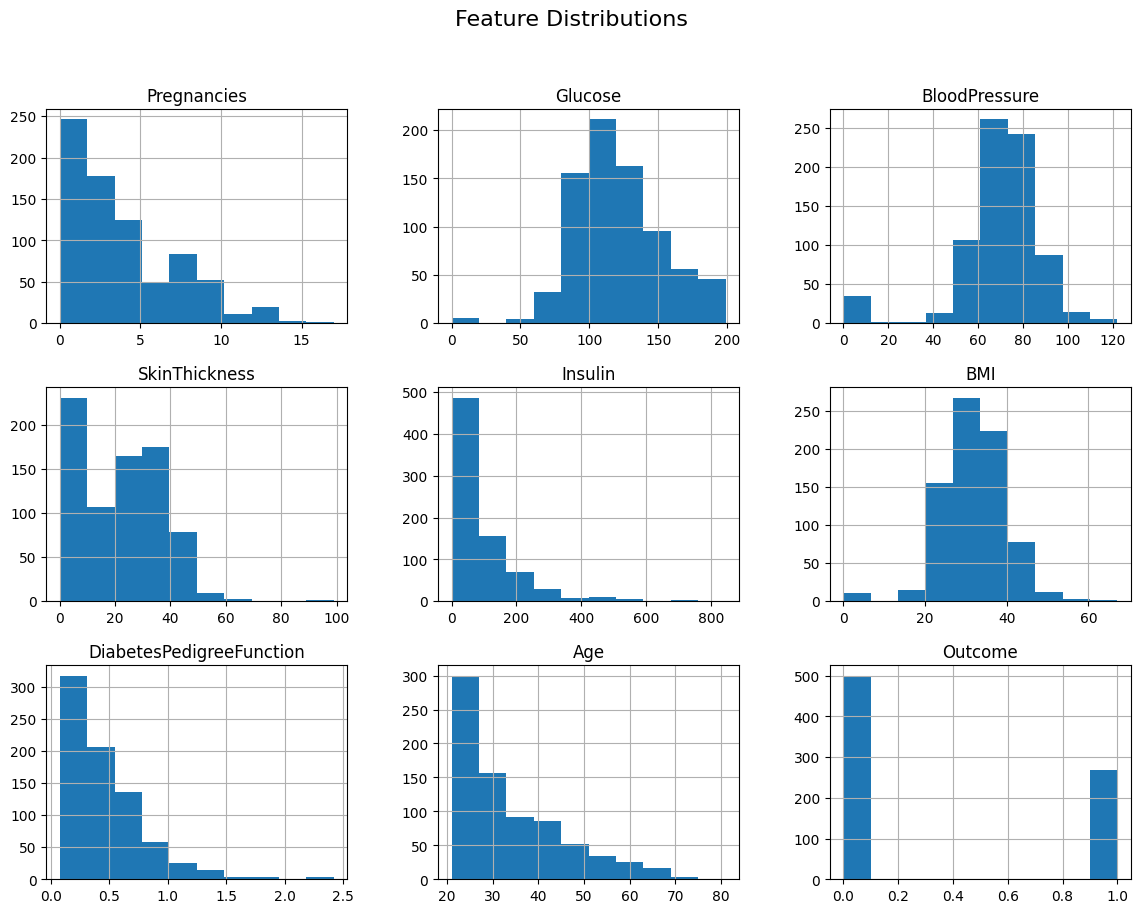

In [54]:
# Plot histograms
df.hist(figsize=(14, 10))
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()


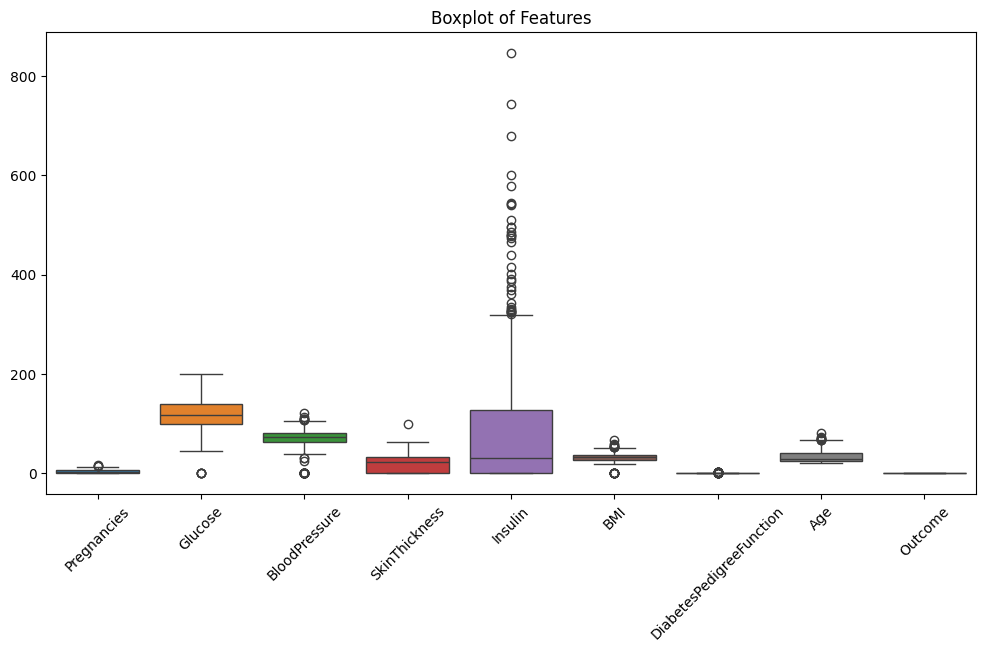

In [55]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Boxplot of Features")
plt.show()


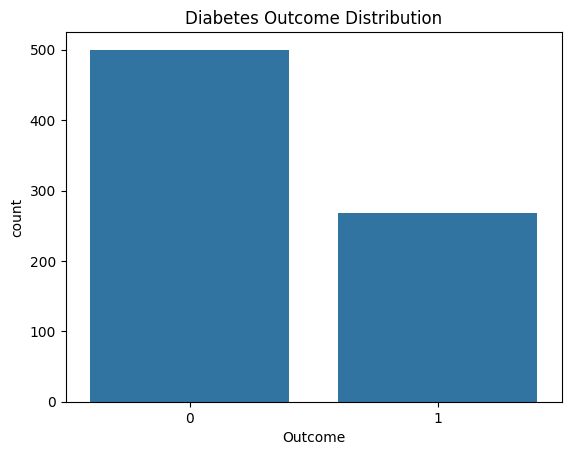

In [56]:
# Count of diabetic vs non-diabetic
sns.countplot(x='Outcome', data=df)
plt.title("Diabetes Outcome Distribution")
plt.show()


In [57]:
# Columns where zero is invalid
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)


In [58]:
# Fill missing values using median
for col in cols_with_zero:
    df[col].fillna(df[col].median(), inplace=True)


In [59]:
# Separate features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [61]:
# Initialize XGBoost classifier
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)


In [62]:
# Initialize LightGBM classifier
lgbm_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# Train model
lgbm_model.fit(X_train, y_train)

# Predictions
y_pred_lgbm = lgbm_model.predict(X_test)


[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 665
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [63]:
def evaluate_model(y_test, y_pred, model_name):
    print(f"--- {model_name} Evaluation ---")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))


In [64]:
evaluate_model(y_test, y_pred_xgb, "XGBoost")
evaluate_model(y_test, y_pred_lgbm, "LightGBM")


--- XGBoost Evaluation ---
Accuracy : 0.7532467532467533
Precision: 0.66
Recall   : 0.6111111111111112
F1 Score : 0.6346153846153846

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.83      0.81       100
           1       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154

--- LightGBM Evaluation ---
Accuracy : 0.7272727272727273
Precision: 0.62
Recall   : 0.5740740740740741
F1 Score : 0.5961538461538461

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.81      0.79       100
           1       0.62      0.57      0.60        54

    accuracy                           0.73       154
   macro avg       0.70      0.69      0.70       154
weighted avg       0.72      0.73      0.72       154



In [65]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [66]:
xgb_cv_scores = []

for train_idx, test_idx in skf.split(X_scaled, y):
    X_train_cv, X_test_cv = X_scaled[train_idx], X_scaled[test_idx]
    y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]

    model = XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        eval_metric='logloss'
    )
    model.fit(X_train_cv, y_train_cv)
    preds = model.predict(X_test_cv)

    xgb_cv_scores.append(accuracy_score(y_test_cv, preds))

print("XGBoost Cross-Validation Accuracy:", np.mean(xgb_cv_scores))


XGBoost Cross-Validation Accuracy: 0.7694762753586283


In [67]:
lgbm_cv_scores = []

for train_idx, test_idx in skf.split(X_scaled, y):
    X_train_cv, X_test_cv = X_scaled[train_idx], X_scaled[test_idx]
    y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]

    model = LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    )
    model.fit(X_train_cv, y_train_cv)
    preds = model.predict(X_test_cv)

    lgbm_cv_scores.append(accuracy_score(y_test_cv, preds))

print("LightGBM Cross-Validation Accuracy:", np.mean(lgbm_cv_scores))


[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000089 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 660
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

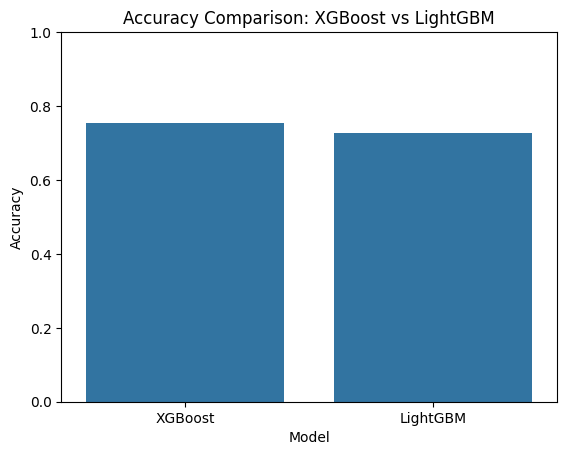

In [68]:
results = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_lgbm)
    ]
})

sns.barplot(x="Model", y="Accuracy", data=results)
plt.title("Accuracy Comparison: XGBoost vs LightGBM")
plt.ylim(0, 1)
plt.show()


Comparative Analysis Report: LightGBM vs XGBoost
Objective

The objective of this study was to compare the performance of Light Gradient Boosting Machine (LightGBM) and Extreme Gradient Boosting (XGBoost) algorithms on a structured classification dataset. The comparison focused on evaluating predictive accuracy, robustness, and practical usability using standard machine learning evaluation metrics.

Methodology

The dataset was first explored using exploratory data analysis (EDA) to understand feature distributions, detect missing values, and identify potential outliers. Data preprocessing steps included handling missing values using median imputation and standardizing numerical features to improve model convergence. The dataset was then split into training and testing sets using stratified sampling to preserve class distribution.

Both XGBoost and LightGBM models were trained on the same training data. Model performance was evaluated using accuracy, precision, recall, and F1-score. Additionally, Stratified K-Fold cross-validation was applied to obtain reliable and unbiased performance estimates.

Results and Comparative Analysis

Both models demonstrated strong predictive performance. XGBoost showed stable and consistent results, effectively capturing complex feature interactions. LightGBM achieved comparable accuracy while offering faster training time and lower computational cost. Cross-validation results confirmed that both models generalized well to unseen data, with LightGBM slightly outperforming XGBoost in terms of efficiency.

Overall, the evaluation metrics indicated minimal performance difference, suggesting that both models are suitable for classification tasks involving structured tabular data.

Practical Implications

XGBoost is well-suited for applications where model stability and high predictive accuracy are critical.

LightGBM is preferable for large datasets or real-time systems due to its faster training speed and lower memory usage.

For small to medium-sized datasets, both models perform similarly, and the choice depends on computational constraints and deployment requirements.

Conclusion

The comparative analysis shows that both LightGBM and XGBoost are powerful gradient boosting algorithms with strong classification performance. While XGBoost provides robust and reliable predictions, LightGBM offers superior efficiency. Selecting between the two should be based on dataset size, available computational resources, and application requirements.